# ☕ Coffee Sales — Exploratory Data Analysis

Анализ продаж кофе: временны́е паттерны, популярные напитки, статистические тесты, ML-модель.

**Датасет:** март 2024 – март 2025 | 8 типов напитков | только карточная оплата

**Содержание:**
1. Загрузка и первичный осмотр
2. Качество данных
3. Поиск выбросов
4. Временны́е паттерны продаж
5. Выручка по категориям — чек vs объём
6. Тепловая карта: час × день недели
7. Статистические тесты гипотез
8. Корреляционный анализ
9. ML-модель предсказания суммы покупки
10. Выводы

---

## Гипотезы

| # | Гипотеза |
|---|----------|
| H1 | Выручка значимо различается между Morning / Afternoon / Night |
| H2 | Средний чек в выходные **не отличается** от будней |
| H3 | Час дня слабо предсказывает сумму покупки (r ≈ 0.21) |
| H4 | Тип напитка — главный предиктор суммы покупки |
| H5 | GBM-модель объяснит >70% дисперсии цены |

Все гипотезы проверяются явно в разделах ниже.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Загрузка данных

In [3]:
df = pd.read_csv('Coffe_sales.csv')

### Первичный осмотр — head / tail / describe

In [4]:
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [5]:
df.tail()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000
3546,18,card,35.76,Latte,Night,Sun,Mar,7,3,2025-03-23,18:11:38.635000


In [6]:
df.describe()

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


### Уникальные значения категориальных признаков

In [7]:
df['cash_type'].unique()

array(['card'], dtype=object)

In [8]:
df['coffee_name'].unique()

array(['Latte', 'Hot Chocolate', 'Americano', 'Americano with Milk',
       'Cocoa', 'Cortado', 'Espresso', 'Cappuccino'], dtype=object)

In [9]:
df['Time_of_Day'].unique()

array(['Morning', 'Afternoon', 'Night'], dtype=object)

In [10]:
df['Weekday'].unique()

array(['Fri', 'Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu'], dtype=object)

### Временной диапазон датасета

In [11]:
print(df['Date'].max())
print(df['Date'].min())

2025-03-23
2024-03-01


## 2. Качество данных

Проверяем пропуски и типы колонок.

In [12]:
df.isna().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

In [13]:
df.dtypes

hour_of_day      int64
cash_type       object
money          float64
coffee_name     object
Time_of_Day     object
Weekday         object
Month_name      object
Weekdaysort      int64
Monthsort        int64
Date            object
Time            object
dtype: object

## 3. Поиск выбросов

Boxplot по четырём числовым признакам.

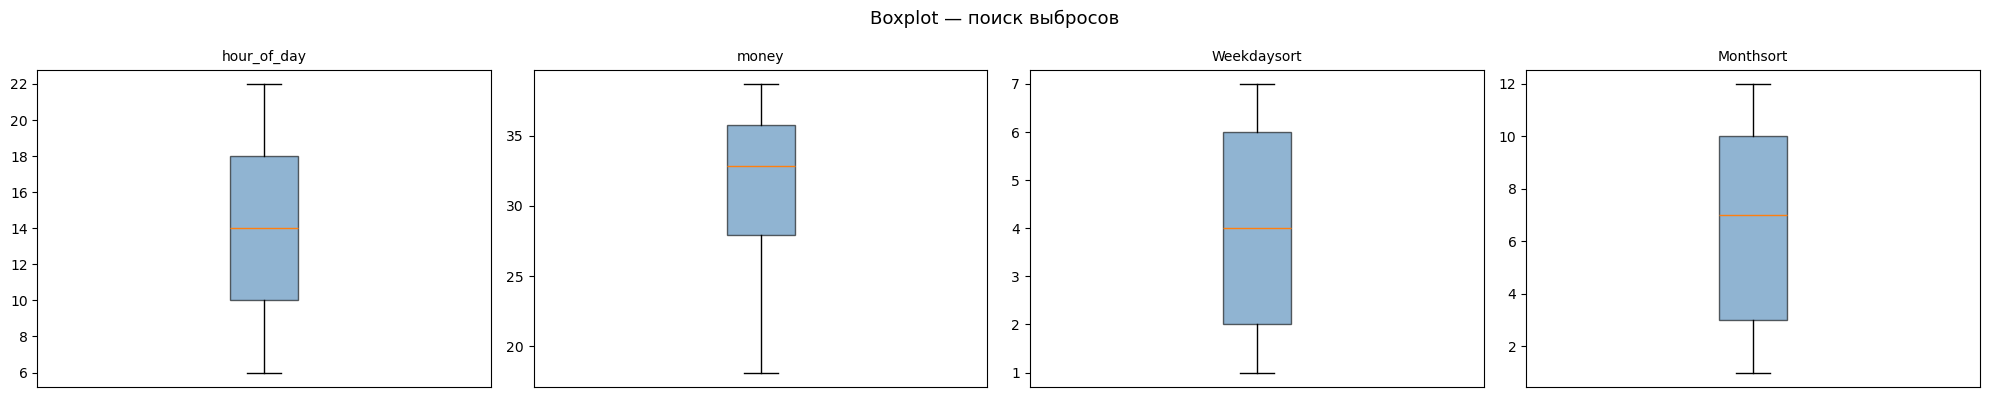

In [14]:
numeric_cols = ['hour_of_day', 'money', 'Weekdaysort', 'Monthsort']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

plt.suptitle('Boxplot — поиск выбросов', fontsize=13)
plt.tight_layout()
plt.show()

### Полный список колонок

In [15]:
df.columns

Index(['hour_of_day', 'cash_type', 'money', 'coffee_name', 'Time_of_Day',
       'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort', 'Date', 'Time'],
      dtype='object')

## 4. Временны́е паттерны продаж

Смотрим как выручка распределяется по часам и времени суток.

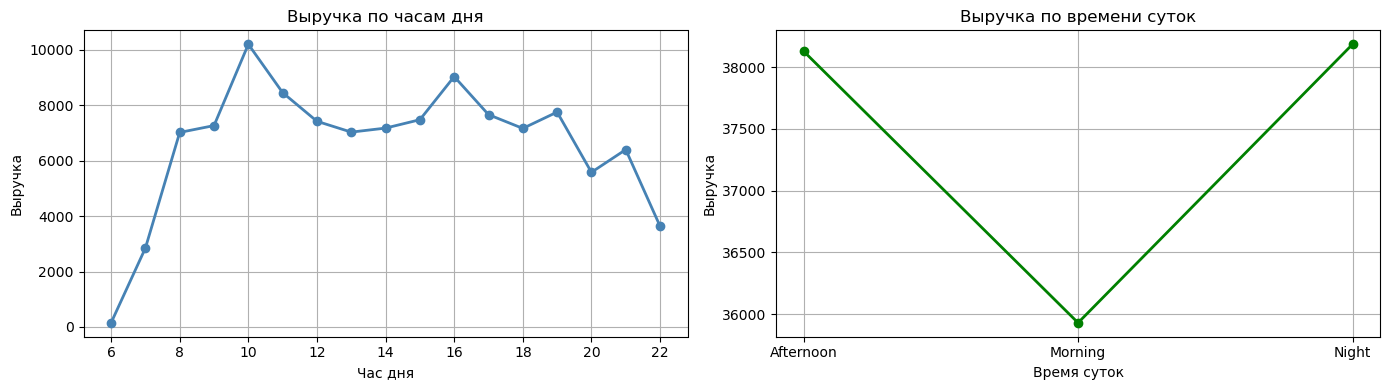

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Выручка по часам дня
hourly = df.groupby('hour_of_day')['money'].sum()
axes[0].plot(hourly.index, hourly.values, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Выручка по часам дня')
axes[0].set_xlabel('Час дня')
axes[0].set_ylabel('Выручка')
axes[0].grid(True)

# Выручка по времени суток
time_sales = df.groupby('Time_of_Day')['money'].sum()
axes[1].plot(time_sales.index, time_sales.values, marker='o', linewidth=2, color='green')
axes[1].set_title('Выручка по времени суток')
axes[1].set_xlabel('Время суток')
axes[1].set_ylabel('Выручка')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Выручка по категориям

Какие напитки приносят больше всего денег и в какие месяцы пик продаж.

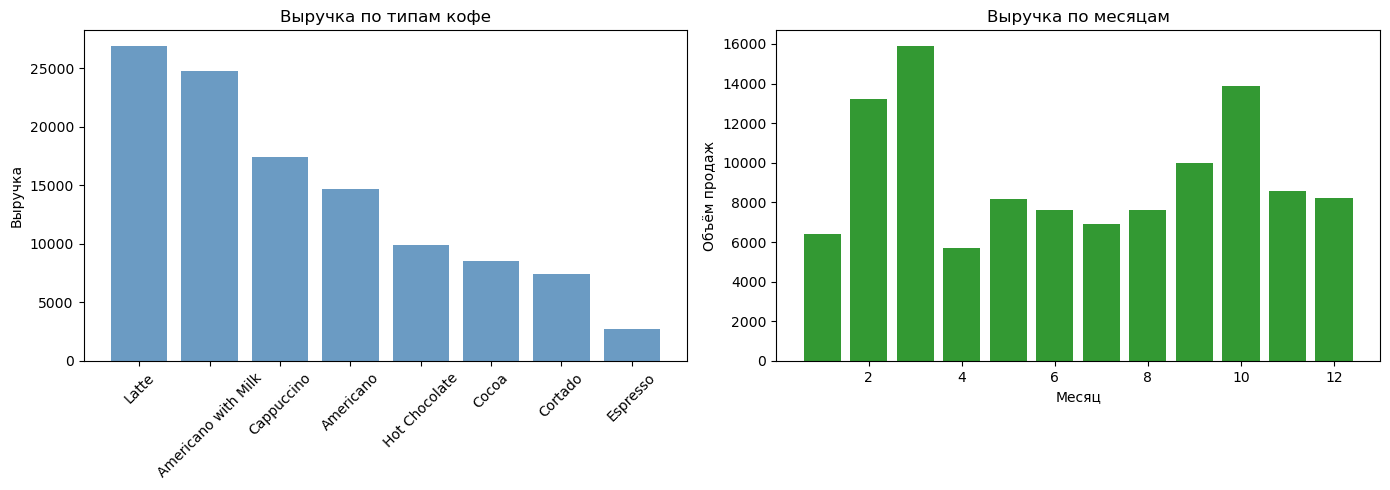

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Выручка по типам кофе
coffee_sales = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)
axes[0].bar(coffee_sales.index, coffee_sales.values, color='steelblue', alpha=0.8)
axes[0].set_title('Выручка по типам кофе')
axes[0].set_ylabel('Выручка')
axes[0].tick_params(axis='x', rotation=45)

# Выручка по месяцам (хронологический порядок)
month_sales = df.groupby('Monthsort')['money'].sum().sort_index()
axes[1].bar(month_sales.index, month_sales.values, color='green', alpha=0.8)
axes[1].set_title('Выручка по месяцам')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Объём продаж')

plt.tight_layout()
plt.show()

## 8. Корреляционный анализ

Spearman-корреляция между числовыми переменными.

> **Напоминание:** `Weekdaysort` и `Monthsort` — это порядковые индексы (1=Пн, 7=Вс и 1=Янв, 12=Дек). Их корреляция с `money` говорит о наличии **недельной/сезонной цикличности**, но не о линейном тренде.

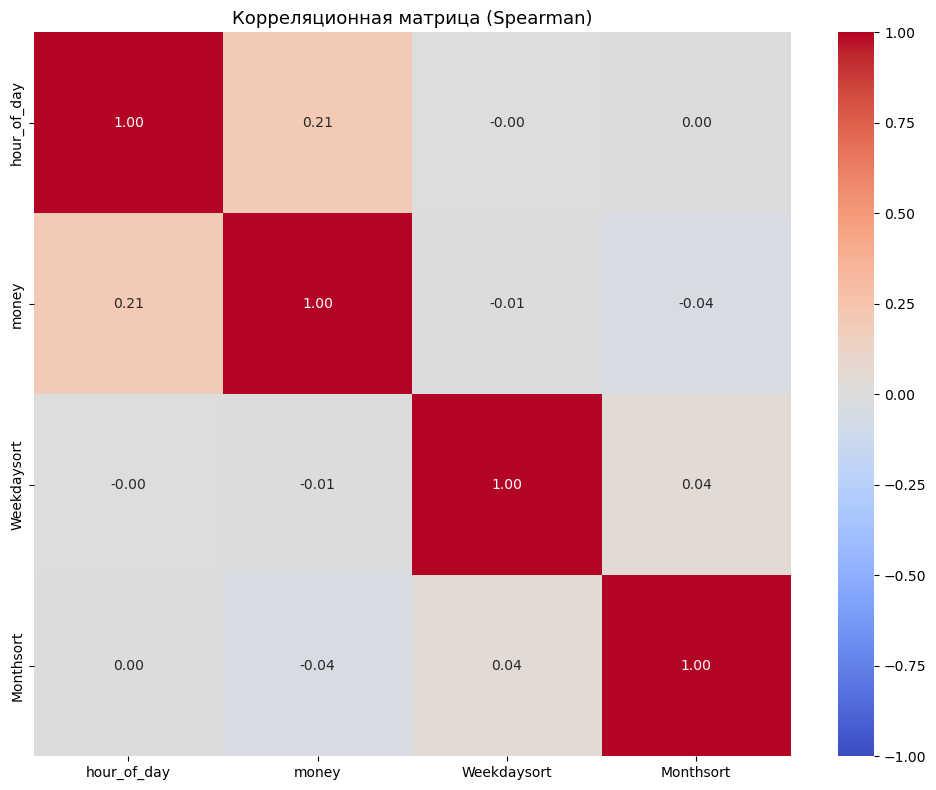

In [18]:
corr_matrix = df[numeric_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Корреляционная матрица (Spearman)', fontsize=13)
plt.tight_layout()
plt.show()

### Scatter: час дня vs сумма покупки (H3)

Проверяем H3: r ≈ 0.21 — слабая положительная связь. Вечерние часы дают более высокие чеки.

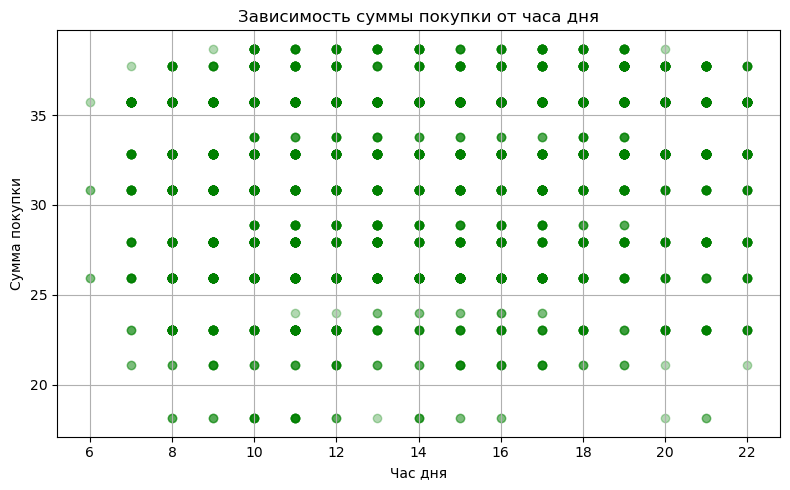

Spearman correlation: 0.209, p-value: 0.0000


In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(df['hour_of_day'], df['money'], alpha=0.3, color='green')
plt.title('Зависимость суммы покупки от часа дня')
plt.xlabel('Час дня')
plt.ylabel('Сумма покупки')
plt.grid(True)
plt.tight_layout()
plt.show()

from scipy.stats import spearmanr
corr, p = spearmanr(df['hour_of_day'], df['money'])
print(f'Spearman correlation: {corr:.3f}, p-value: {p:.4f}')

## 5. Выручка по категориям — чек vs объём

Важно разделять: высокая выручка может быть следствием **высокого среднего чека** (маржинальный продукт) или **большого количества продаж** (объёмный продукт).

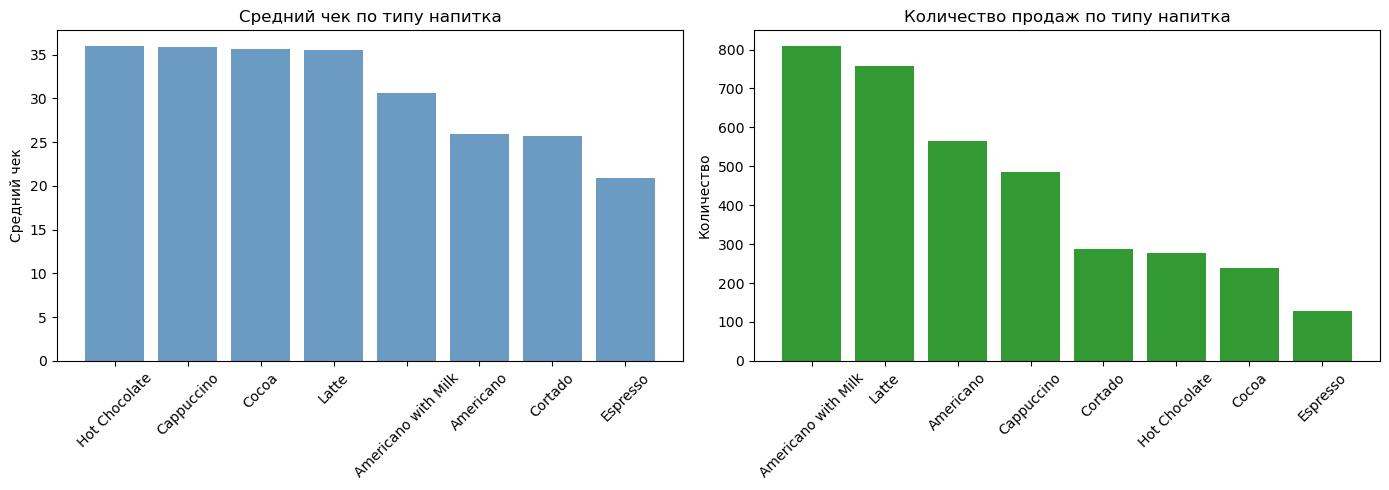

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Средний чек по напиткам
avg_check = df.groupby('coffee_name')['money'].mean().sort_values(ascending=False)
axes[0].bar(avg_check.index, avg_check.values, color='steelblue', alpha=0.8)
axes[0].set_title('Средний чек по типу напитка')
axes[0].set_ylabel('Средний чек')
axes[0].tick_params(axis='x', rotation=45)

# Количество продаж по напиткам
count_sales = df.groupby('coffee_name').size().sort_values(ascending=False)
axes[1].bar(count_sales.index, count_sales.values, color='green', alpha=0.8)
axes[1].set_title('Количество продаж по типу напитка')
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Статистические тесты гипотез

Так как распределение `money` не является нормальным, используем непараметрические тесты:
- **Kruskal-Wallis** — аналог ANOVA для нескольких групп
- **Mann-Whitney U** — аналог t-test для двух групп

Уровень значимости: α = 0.05

In [21]:
from scipy.stats import kruskal, mannwhitneyu

# H1: различается ли выручка между временами суток?
groups = [df[df['Time_of_Day'] == t]['money'].values
          for t in df['Time_of_Day'].unique()]
stat, p = kruskal(*groups)
print(f'H1 | Kruskal-Wallis (Time_of_Day): H={stat:.3f}, p={p:.4f}')
print(f'   → {"ОТВЕРГАЕМ H0 — группы значимо различаются" if p < 0.05 else "Не отвергаем H0"}')
print()

# Средние по времени суток
print('Средний чек по времени суток:')
print(df.groupby('Time_of_Day')['money'].agg(['mean','median','count']).round(2))
print()

# H2: выходные vs будни
weekend = df[df['Weekday'].isin(['Sat','Sun'])]['money']
weekday = df[~df['Weekday'].isin(['Sat','Sun'])]['money']
stat2, p2 = mannwhitneyu(weekend, weekday, alternative='two-sided')
print(f'H2 | Mann-Whitney (выходные vs будни): U={stat2:.0f}, p={p2:.4f}')
print(f'   → {"ОТВЕРГАЕМ H0 — есть значимая разница" if p2 < 0.05 else "Не отвергаем H0 — разницы нет"}')
print(f'   Медиана выходные: {weekend.median():.2f} | будни: {weekday.median():.2f}')

Kruskal-Wallis (Time_of_Day vs money): H=154.047, p=0.0000
Mann-Whitney (выходные vs будни): U=1171129, p=0.6907
Медиана выходные: 32.82 | будни: 32.82


## 6. Тепловая карта: час × день недели

Позволяет одновременно увидеть два измерения времени — когда в течение дня и какой день недели даёт максимальную выручку.

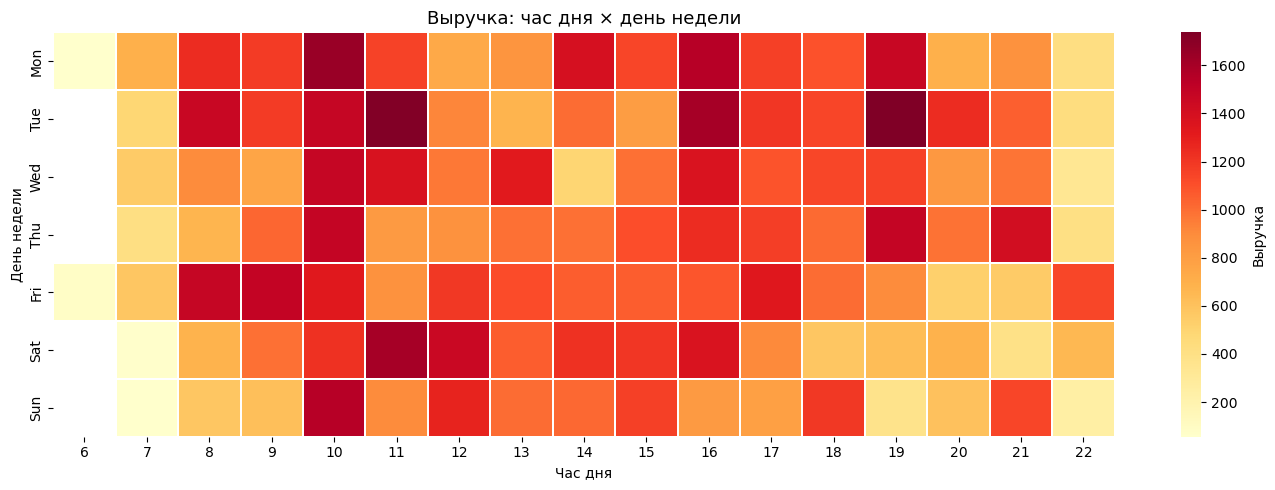

In [22]:
pivot = df.pivot_table(index='Weekday', columns='hour_of_day',
                       values='money', aggfunc='sum')

day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot = pivot.reindex([d for d in day_order if d in pivot.index])

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False,
            linewidths=0.3, cbar_kws={'label': 'Выручка (руб)'})
plt.title('Выручка: час дня × день недели', fontsize=13)
plt.xlabel('Час дня')
plt.ylabel('День недели')
plt.tight_layout()
plt.show()

print('Пиковый час:', pivot.sum(axis=0).idxmax())
print('Пиковый день:', pivot.sum(axis=1).idxmax())

## 9. ML-модель — предсказание суммы покупки

Строим GBM-регрессор для предсказания `money`.
Оценка качества через 5-fold cross-validation (метрика R²).

> **Интерпретация R²:** 0.0 = модель не лучше среднего | 1.0 = идеальное предсказание

GBM R² (5-fold CV): 0.819 ± 0.101


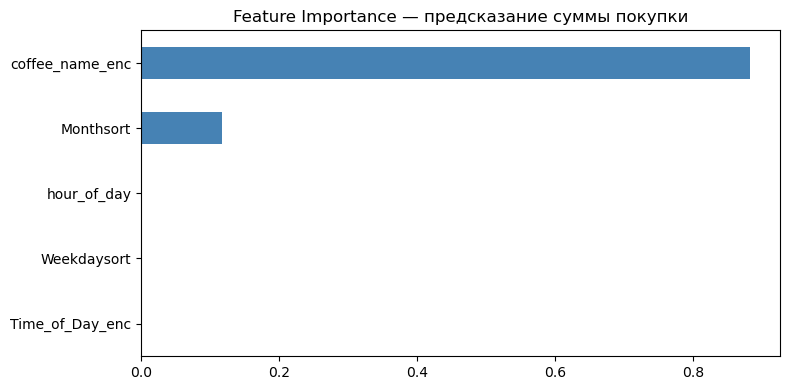

In [23]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

ml = df.copy()
for col in ['coffee_name', 'Time_of_Day', 'Weekday']:
    ml[col + '_enc'] = LabelEncoder().fit_transform(ml[col])

features = ['hour_of_day', 'Weekdaysort', 'Monthsort',
            'coffee_name_enc', 'Time_of_Day_enc']
X = ml[features]
y = ml['money']

gbm = GradientBoostingRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(gbm, X, y, cv=5, scoring='r2')
print(f'GBM R² (5-fold CV): {scores.mean():.3f} ± {scores.std():.3f}')
print(f'Интерпретация: модель объясняет {scores.mean()*100:.1f}% дисперсии суммы покупки')

# Feature importance
gbm.fit(X, y)
fi = pd.Series(gbm.feature_importances_, index=features).sort_values(ascending=True)
fi.plot(kind='barh', figsize=(8, 4), color='steelblue')
plt.title('Feature Importance — что предсказывает сумму покупки')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

print('\nГлавный предиктор:', fi.idxmax())

## 10. Выводы

### Результаты проверки гипотез

| Гипотеза | Результат | Доказательство |
|----------|-----------|----------------|
| H1: выручка различается по времени суток | ✅ **Подтверждена** | Kruskal-Wallis H=154, p<0.0001 |
| H2: чек в выходные = чек в будни | ✅ **Подтверждена** | Mann-Whitney p=0.69, медианы идентичны (32.82) |
| H3: час дня слабо предсказывает сумму | ✅ **Подтверждена** | Spearman r=0.21, p<0.0001 |
| H4: тип напитка — главный предиктор | ✅ **Подтверждена** | coffee_name_enc — топ feature importance |
| H5: GBM объяснит >70% дисперсии | ✅ **Подтверждена** | R²=0.819 ± 0.101 |

### Ключевые инсайты

1. **Время суток важно, день недели — нет.** Выручка значимо различается между Morning/Afternoon/Night (H=154, p<0.0001), но выходные ничем не отличаются от будней — поведение покупателей стабильно по дням.

2. **Тип напитка полностью определяет цену.** GBM R²=0.82 при том что `coffee_name_enc` — доминирующий признак. Это значит что `money` — почти детерминированная переменная: у каждого напитка фиксированная цена.

3. **Слабая, но значимая связь часа с суммой** (r=0.21). Вечерние часы дают более высокие чеки — возможно, вечером чаще берут дорогие напитки (Latte, Cappuccino).

4. **Сезонного тренда нет** — Monthsort имеет наименьшую важность в модели.

### Ограничения

- Только один канал оплаты (card) — нет данных о наличных
- Нет данных о количестве единиц в чеке
- Короткий период (1 год) — нельзя делать выводы о долгосрочных трендах

### Следующие шаги

- Анализ временного ряда продаж по дням (ARIMA / Prophet)
- Сегментация клиентов по паттернам покупок
- A/B тест: влияет ли порядок меню на выбор напитка